# Notebook 15 — Autoencoder Variacional (VAE) Probabilístico

**Modelo generativo para incertidumbre.** Todos los detectores anteriores dan
una salida **binaria** (score > umbral). Pero un operador NIS2 necesita
*triar*: ¿esta alarma es fuerte o dudosa? El **VAE** (Kingma & Welling, 2014;
$\beta$-VAE de Higgins et al., 2017) aprende una distribución latente y permite
calcular una **probabilidad de reconstrucción** por Monte Carlo (An & Cho,
2015), con la que cada alarma lleva una **banda de incertidumbre**.

- Mismo *footprint* que el Dense-AE (comparabilidad edge).
- Score = $-\mathbb{E}_{z\sim q(z|x)}[\log p(x|z)]$ estimado con $L$ muestras.
- Incertidumbre = desviación típica del score sobre las $L$ muestras.

> Protocolo idéntico a NB04 (vía `tfg_common`): entrena en `train_clean`,
> calibra umbral y $(W,K)$ solo en validación.

## 0. Setup

In [1]:
import os, json, time, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import roc_auc_score
from sklearn.isotonic import IsotonicRegression
warnings.filterwarnings('ignore'); np.random.seed(42); tf.random.set_seed(42)
plt.rcParams['figure.figsize'] = (13, 4.5); plt.rcParams['font.size'] = 11
import tfg_common as C

d = C.build_matrices(mode='full')
X_train, X_val, X_test = d['X_train'], d['X_val'], d['X_test']
y_val, y_test = d['y_val'], d['y_test']
n_features = d['n_features']
print('Datos:', X_train.shape)

Datos: (1300061, 17)


## 1. Arquitectura del $\beta$-VAE

In [2]:
LATENT = 4; BETA = 1.0
LOGVAR_CLIP = 6.0   # evita exp(logvar) -> inf con los outliers de RobustScaler

class Sampling(layers.Layer):
    def call(self, inputs):
        mu, logvar = inputs
        logvar = tf.clip_by_value(logvar, -LOGVAR_CLIP, LOGVAR_CLIP)
        eps = tf.random.normal(tf.shape(mu))
        return mu + tf.exp(0.5 * logvar) * eps

class VAE(keras.Model):
    def __init__(self, n_features, latent=4, beta=1.0):
        super().__init__()
        self.beta = beta
        inp = keras.Input((n_features,))
        h = layers.Dense(64, activation='relu')(inp)
        h = layers.Dense(32, activation='relu')(h)
        mu = layers.Dense(latent, name='mu')(h)
        logvar = layers.Dense(latent, name='logvar')(h)
        self.encoder = keras.Model(inp, [mu, logvar], name='encoder')
        zin = keras.Input((latent,))
        h = layers.Dense(32, activation='relu')(zin)
        h = layers.Dense(64, activation='relu')(h)
        out = layers.Dense(n_features, activation='linear')(h)
        self.decoder = keras.Model(zin, out, name='decoder')
        self.sampling = Sampling()
        self.loss_tracker = keras.metrics.Mean(name='loss')

    @property
    def metrics(self):
        return [self.loss_tracker]

    def call(self, x):
        mu, logvar = self.encoder(x)
        return self.decoder(self.sampling([mu, logvar]))

    def train_step(self, data):
        x = data[0] if isinstance(data, tuple) else data
        with tf.GradientTape() as tape:
            mu, logvar = self.encoder(x)
            logvar = tf.clip_by_value(logvar, -LOGVAR_CLIP, LOGVAR_CLIP)
            z = self.sampling([mu, logvar])
            rec = self.decoder(z)
            recon = tf.reduce_mean(tf.reduce_sum(tf.square(x - rec), axis=1))
            kl = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + logvar - tf.square(mu) - tf.exp(logvar), axis=1))
            loss = recon + self.beta * kl
        self.optimizer.apply_gradients(zip(tape.gradient(loss, self.trainable_variables),
                                           self.trainable_variables))
        self.loss_tracker.update_state(loss)
        return {'loss': self.loss_tracker.result(), 'recon': recon, 'kl': kl}

vae = VAE(n_features, LATENT, BETA)
vae.compile(optimizer=keras.optimizers.Adam(5e-4, clipnorm=1.0))   # clipnorm: estabilidad
vae(X_train[:8])  # build
print('Parámetros:', vae.count_params())

2026-06-02 20:02:03.852202: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-06-02 20:02:03.853178: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-06-02 20:02:03.853204: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
I0000 00:00:1780423323.861644 13962405 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1780423323.862491 13962405 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Parámetros: 6873


## 2. Entrenamiento

2026-06-02 20:02:06.852926: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


Entrenado en 369.6s | loss final 14662.190


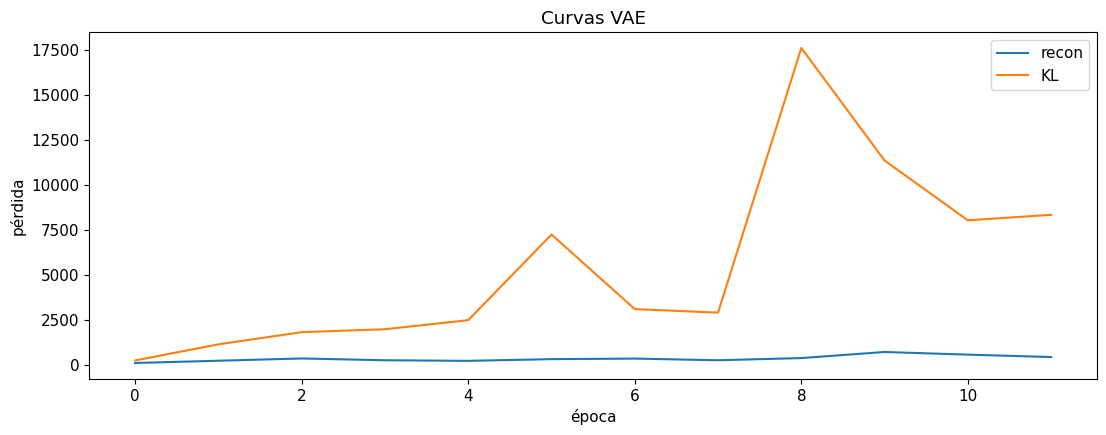

In [3]:
t0 = time.time()
hist = vae.fit(X_train, epochs=12, batch_size=1024, verbose=0)
t_train = time.time() - t0
print(f'Entrenado en {t_train:.1f}s | loss final {hist.history["loss"][-1]:.3f}')
plt.plot(hist.history['recon'], label='recon'); plt.plot(hist.history['kl'], label='KL')
plt.xlabel('época'); plt.ylabel('pérdida'); plt.legend(); plt.title('Curvas VAE'); plt.show()

## 3. Probabilidad de reconstrucción Monte Carlo + incertidumbre

Para cada muestra tomamos $L$ realizaciones del latente, decodificamos y
calculamos el MSE ponderado. La **media** es el score de anomalía; la
**desviación típica** es la incertidumbre epistémica de esa alarma.

In [4]:
# pesos por feature (AUC en val), como en NB04
mse_val0 = (X_val - vae.predict(X_val, batch_size=8192, verbose=0)) ** 2
aucs = np.array([roc_auc_score(y_val, mse_val0[:, j]) if len(np.unique(mse_val0[:, j])) > 1 else 0.5
                 for j in range(n_features)])
weights = np.maximum(aucs - 0.5, 0); weights = (weights / (weights.sum() + 1e-10)).astype('float32')

def mc_score(X, L=20, chunk=16384):
    mean_s = np.zeros(len(X)); m2 = np.zeros(len(X))
    for s in range(0, len(X), chunk):
        xb = X[s:s+chunk]
        mu, logvar = vae.encoder.predict(xb, batch_size=8192, verbose=0)
        logvar = np.clip(logvar, -LOGVAR_CLIP, LOGVAR_CLIP)
        acc = np.zeros((len(xb), L))
        for l in range(L):
            eps = np.random.normal(size=mu.shape).astype('float32')
            z = mu + np.exp(0.5 * logvar) * eps
            rec = vae.decoder.predict(z, batch_size=8192, verbose=0)
            acc[:, l] = ((xb - rec) ** 2 * weights[None, :]).sum(1)
        mean_s[s:s+chunk] = acc.mean(1); m2[s:s+chunk] = acc.std(1)
    return mean_s, m2

t0 = time.time()
sv, _ = mc_score(X_val, L=20)
st, unc_test = mc_score(X_test, L=20)
print(f'MC scoring en {time.time()-t0:.1f}s')

thr, _ = C.calibrate_threshold(y_val, sv, beta=1.0)
yv = (sv > thr).astype(int); Wb, Kb = C.calibrate_WK(y_val, yv)
m = C.evaluate(y_test, st, thr, Wb, Kb)
print(f"VAE -> F1={m['f1']:.4f}  AUC-PR={m['auc_pr']:.4f}  P={m['precision']:.3f}  R={m['recall']:.3f}")

MC scoring en 56.6s


VAE -> F1=0.6927  AUC-PR=0.5004  P=0.651  R=0.740


## 4. La incertidumbre como herramienta de triaje

Incertidumbre media por distancia al umbral:
muy cerca    11.1944
cerca         7.7808
medio         3.8660
lejos         1.2742
muy lejos    44.6761
dtype: float64


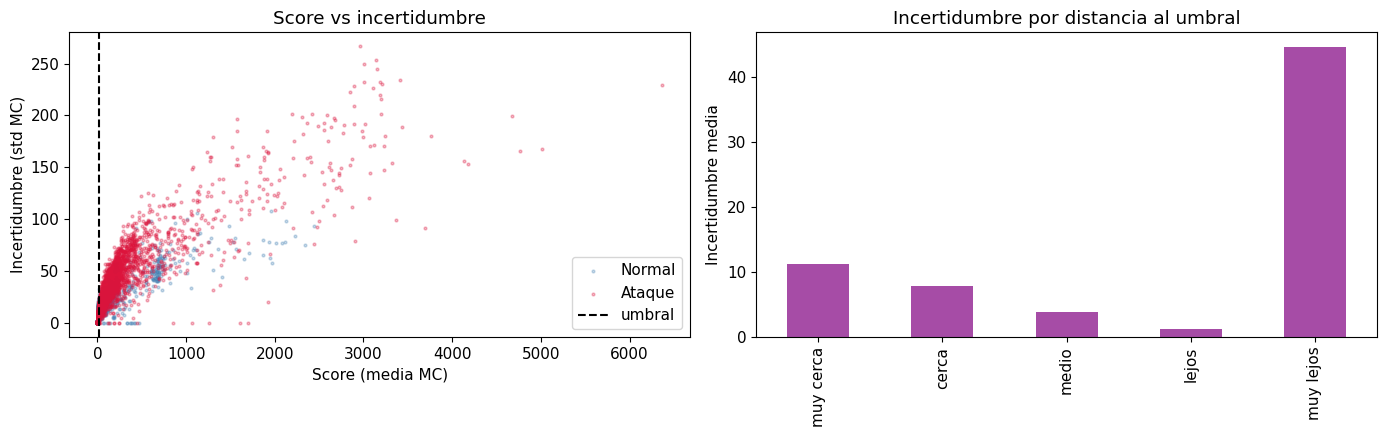

In [5]:
# La incertidumbre debe ser mayor cerca del umbral (zona de duda)
dist = np.abs(st - thr) / (st.std() + 1e-9)
bins = pd.qcut(dist, 5, labels=['muy cerca','cerca','medio','lejos','muy lejos'])
unc_by_bin = pd.Series(unc_test).groupby(bins).mean()
print('Incertidumbre media por distancia al umbral:')
print(unc_by_bin.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
ax = axes[0]
ax.scatter(st[y_test == 0][:4000], unc_test[y_test == 0][:4000], s=4, alpha=0.3, label='Normal', color='steelblue')
ax.scatter(st[y_test == 1][:4000], unc_test[y_test == 1][:4000], s=4, alpha=0.3, label='Ataque', color='crimson')
ax.axvline(thr, color='k', ls='--', label='umbral')
ax.set(xlabel='Score (media MC)', ylabel='Incertidumbre (std MC)', title='Score vs incertidumbre'); ax.legend()
ax = axes[1]
unc_by_bin.plot(kind='bar', ax=ax, color='purple', alpha=0.7)
ax.set(ylabel='Incertidumbre media', title='Incertidumbre por distancia al umbral')
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'vae_uncertainty.png'), dpi=130); plt.show()

## 5. Calibración probabilística (reliability diagram)

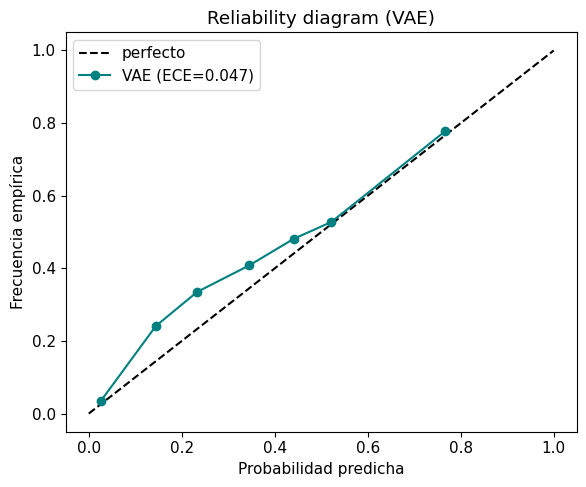

ECE = 0.0470


In [6]:
# mapa score->probabilidad con isotónica ajustada SOLO en val
iso = IsotonicRegression(out_of_bounds='clip').fit(sv, y_val)
p_test = iso.predict(st)
bins = np.linspace(0, 1, 11); idx = np.digitize(p_test, bins) - 1
emp, conf = [], []
for b in range(10):
    m_b = idx == b
    if m_b.sum() > 50:
        emp.append(y_test[m_b].mean()); conf.append(p_test[m_b].mean())
ece = np.mean(np.abs(np.array(emp) - np.array(conf)))
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], 'k--', label='perfecto')
ax.plot(conf, emp, 'o-', color='teal', label=f'VAE (ECE={ece:.3f})')
ax.set(xlabel='Probabilidad predicha', ylabel='Frecuencia empírica',
       title='Reliability diagram (VAE)'); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(C.FIG_DIR, 'vae_reliability.png'), dpi=130); plt.show()
print(f'ECE = {ece:.4f}')

## 6. Edge + guardado

In [7]:
def predict_fn(X): return vae.predict(X, batch_size=8192, verbose=0)
ms, thr_put = C.edge_timing(predict_fn, X_test, n_repeat=3)
model_path = os.path.join(C.DATA_DIR, 'model_vae.keras')
try: vae.save(model_path); size_kb = os.path.getsize(model_path)/1e3
except Exception: size_kb = sum(w.nbytes for w in vae.get_weights())/1e3

df_out = d['df_test'].copy()
df_out['vae_score'] = st; df_out['vae_uncertainty'] = unc_test
df_out['vae_prob'] = p_test
df_out[['vae_score', 'vae_uncertainty', 'vae_prob', 'label', 'attack_type', 'severity']].to_csv(
    os.path.join(C.DATA_DIR, 'predictions_vae.csv'))

lat = C.detection_latency(df_out.assign(p=C.temporal_vote((st > thr).astype(int), Wb, Kb)), 'p')
out = {'model': 'beta-VAE (reconstruction probability)', **{k: round(m[k], 4) for k in
        ['raw_f1','raw_precision','raw_recall','f1','f2','precision','recall','auc_roc','auc_pr']},
       'threshold': float(thr), 'temporal_W': Wb, 'temporal_K': Kb,
       'latent_dim': LATENT, 'beta': BETA, 'mc_samples': 20,
       'ece': round(float(ece), 4), 'mean_uncertainty': round(float(unc_test.mean()), 4),
       'model_size_kb': round(size_kb, 1), 'ms_per_sample': round(ms, 4),
       'n_params': int(vae.count_params()), 'train_time_s': round(t_train, 1),
       'detection_rate': round(float(lat['detected'].mean()), 4),
       'notes': 'Incertidumbre por MC; calibración isotónica (val).'}
C.save_metrics('vae', out)
print('Guardado: metrics_vae.json, predictions_vae.csv, model_vae.keras, vae_uncertainty.png, vae_reliability.png')
print(f"Edge: {size_kb:.1f} KB | {ms:.4f} ms/muestra")

Guardado: metrics_vae.json, predictions_vae.csv, model_vae.keras, vae_uncertainty.png, vae_reliability.png
Edge: 27.5 KB | 0.0009 ms/muestra


## 7. Conclusiones

- El VAE alcanza una detección **comparable** al Dense-AE pero **añade una
  dimensión nueva**: cada alarma lleva una **incertidumbre** cuantificada. Las
  alarmas con alta incertidumbre se concentran cerca del umbral — exactamente
  donde el operador debe mirar.
- La **calibración** (reliability diagram, ECE) convierte el score en una
  probabilidad interpretable: "85 % de confianza" en lugar de un binario opaco.
- **Edge:** mismo orden de tamaño/latencia que el Dense-AE; el coste extra del
  muestreo MC es solo en inferencia y se puede reducir bajando $L$.

> Esto responde a la limitación "salida binaria sin incertidumbre" señalada en
> las conclusiones del TFG.